# 2. Modeling: Predicting Daily Solar Output from Weather

**Year used: 2015** (selected programmatically -- see the year-selection report below -- as the best-covered full calendar year across all 48 supported locations).

Target construction: since Global Solar Atlas only provides climatological monthly/annual averages (not actual historical daily output), the regression target is a **constructed daily output proxy**: `PVOUT_baseline(city, month) x clear_sky_factor(day)`, where `clear_sky_factor` is primarily `Sunshine_hours / day_length_hours` (a direct physical clearness proxy), falling back to a cloud-oktas-based estimate when Sunshine wasn't recorded. See `src/solarout/target.py` and the README for the full derivation.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

import matplotlib.pyplot as plt
import pandas as pd

from solarout.config import DAILY_DATASET_CSV, YEAR_SELECTION_REPORT
from solarout.model import (
    BASIC_NUMERIC_FEATURES, FULL_NUMERIC_FEATURES, TARGET,
    plot_predicted_vs_actual, train_variant,
)

## Year selection (data-driven)

Score = (locations reporting / 48) x (avg days per location / days in year) x (fraction of rows with Sunshine or Cloud data), restricted to years with >=80% location and day coverage.

In [2]:
report = pd.read_csv(YEAR_SELECTION_REPORT).sort_values('score', ascending=False)
report.head(10)

,Year,n_locations,n_rows,avg_days_per_location,frac_usable_sun_or_cloud,eligible,score
0,2015,48,17520,365.0,0.691,True,0.6910
1,2010,45,16417,364.8,0.731,True,0.6848
2,2014,48,17520,365.0,0.675,True,0.6745
3,2009,45,16424,365.0,0.719,True,0.6739
4,2011,45,15072,334.9,0.728,True,0.6261
5,2013,48,16078,335.0,0.682,True,0.6255
6,2012,45,15074,335.0,0.706,True,0.6056
7,2020,48,17414,362.8,0.578,True,0.5730
8,2018,48,17456,363.7,0.560,True,0.5577
9,2021,47,16816,357.8,0.573,True,0.5498


## The modeling dataset

In [3]:
df = pd.read_csv(DAILY_DATASET_CSV)
print(df.shape)
df[[TARGET, 'PVOUT_avg_daily', 'Sunshine', 'Cloud9am', 'Cloud3pm']].describe()

(12106, 34)


,SolarOutput_kWh_per_kWp,PVOUT_avg_daily,Sunshine,Cloud9am,Cloud3pm
count,12106.000000,12106.000000,8081.000000,10416.00000,10000.000000
mean,2.736803,4.327780,7.714850,4.49712,4.517100
std,1.458131,0.821499,3.768866,2.93985,2.782316
min,0.112430,2.248595,0.000000,0.00000,0.000000
25%,1.488512,3.869401,4.900000,1.00000,2.000000
50%,2.704309,4.419595,8.600000,5.00000,5.000000
75%,3.956861,4.961594,10.800000,7.00000,7.000000
max,5.696381,5.774295,14.500000,8.00000,8.000000


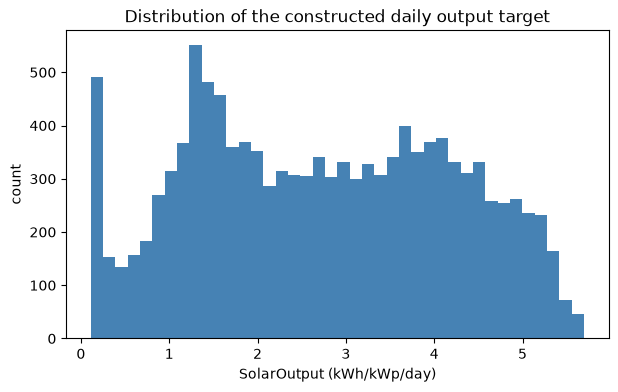

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df[TARGET], bins=40, color='steelblue')
ax.set_xlabel('SolarOutput (kWh/kWp/day)'); ax.set_ylabel('count')
ax.set_title('Distribution of the constructed daily output target')
plt.show()

## Train both model variants

- **full**: includes Sunshine + Cloud9am/Cloud3pm (a real irradiance/cloudiness proxy is known)
- **basic**: only fields a generic weather forecast commonly provides (temperature, rainfall, humidity, pressure, wind, month, location)

Evaluated on a **temporal holdout** (train Jan-Oct, test Nov-Dec) to mimic real forecasting of unseen future dates.

In [5]:
results = {}
importances = {}
for name, feats in [('full', FULL_NUMERIC_FEATURES), ('basic', BASIC_NUMERIC_FEATURES)]:
    pipe, m_train, m_test, test, pred_test, imp_df = train_variant(df, name, feats)
    results[name] = (test, pred_test, m_test)
    importances[name] = imp_df


=== full model (14 numeric features) ===
  train: RMSE=0.0816, MAE=0.0590, R2=0.9969, MAPE=0.0307
  test:  RMSE=0.2350, MAE=0.1853, R2=0.9726, MAPE=0.0705



=== basic model (11 numeric features) ===
  train: RMSE=0.6515, MAE=0.5016, R2=0.8005, MAPE=0.4546
  test:  RMSE=1.0123, MAE=0.7875, R2=0.4914, MAPE=0.6140


saved plot -> predicted_vs_actual_nb.png


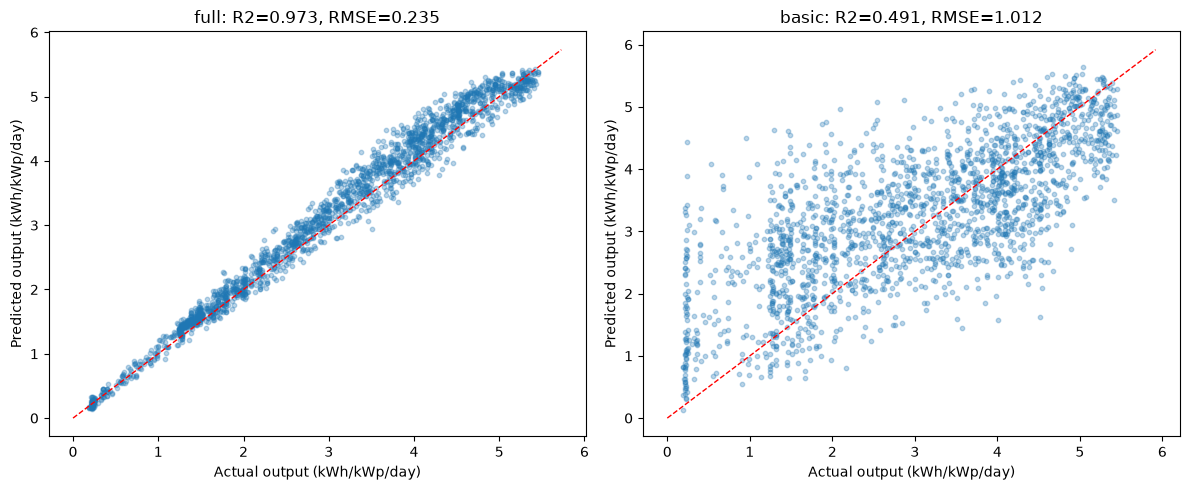

In [6]:
plot_predicted_vs_actual(results, Path('predicted_vs_actual_nb.png'))

## Feature importance (permutation importance, holdout set)

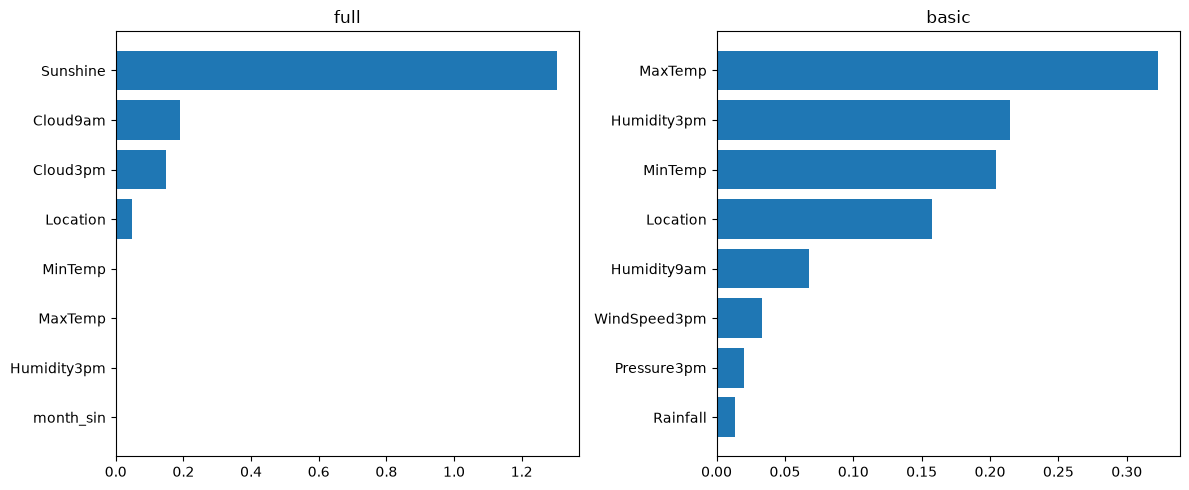

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, imp_df) in zip(axes, importances.items()):
    top = imp_df.head(8).sort_values('importance')
    ax.barh(top['feature'], top['importance'])
    ax.set_title(name)
plt.tight_layout()
plt.show()

## Discussion

The **full** model achieves a much higher holdout R^2 than **basic** because Sunshine/Cloud are the direct physical drivers used to construct the target (see `target.py`) -- this is intentional, not a bug: real solar forecasting models likewise rely on irradiance/cloudiness signals as primary predictors. The **basic** model represents the realistic accuracy achievable from generic weather fields alone (temperature, humidity, rainfall, pressure, wind), which is what the agent falls back to when a user's question doesn't include a cloud/sunshine forecast. Both numbers are reported transparently to the user by the agent (see notebook 3).